# TAS1 Price and Basslink Flow Forecasting

Tasmania's electricity market is structurally weird: ~80% hydro with
reservoir storage, ~17% wind, and a single 500 MW HVDC link to
Victoria. Most of the time TAS1 prices are close to VIC1 prices.
Every time Basslink congests, TAS1 detaches.

This notebook is laid out as a short paper —
**Introduction**, **Data**, **Methods**, **Results**, **Conclusion** —
but inside Methods it walks through **seven progressively richer
techniques**, each one answering a question the previous one couldn't:

> spectral characterisation → Bayesian state-space model →
> gradient boosting → quantile gradient boosting → conformal
> calibration → temporal CNN → graph neural network.

Every plot is read out loud: *what to look at, what it means, what
it indicates next.*

## 1. Introduction

*The forecasting problem, why Tasmania is a good case study, and
what each method is set up to deliver.*

The unifying question is short: **forecast next-period TAS1 RRP and
Basslink flow direction, with calibrated uncertainty, and explain
how much variance each technique unlocks**. The point is not to pick
a winner — it is to demonstrate that different techniques answer
different questions:

- Where does the *price* live in time-frequency space? → spectral.
- When and *how* does TAS1 detach from VIC1? → Bayesian state-space.
- How well can a strong tabular model do on engineered features?
  → gradient boosting.
- What's the model's actual uncertainty? → quantile-GB + conformal.
- Does temporal structure beyond what hand-crafted lags capture
  add value? → temporal CNN.
- Does cross-region contagion add value beyond pure-local features?
  → GNN over the NEM regional graph.

## 2. Data

*30-minute trading intervals from AEMO via NEMOSIS for 2024.*

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data
import models
import plots
import spectral
import bayes_dlm
import conformal
import tcn
import gnn

plots.apply_style()

df = data.load("2024/01/01 00:00:00", "2025/01/01 00:00:00")
print(f"rows: {len(df):,}  range: {df['SETTLEMENTDATE'].min()} -> {df['SETTLEMENTDATE'].max()}")

INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Returning DISPATCHREGIONSUM.
INFO: Compiling data for table DISPATCHINTERCONNECTORRES
INFO: Returning DISPATCHINTERCONNECTORRES.
rows: 17,568  range: 2024-01-01 00:30:00 -> 2025-01-01 00:00:00


### 2.1 The series itself

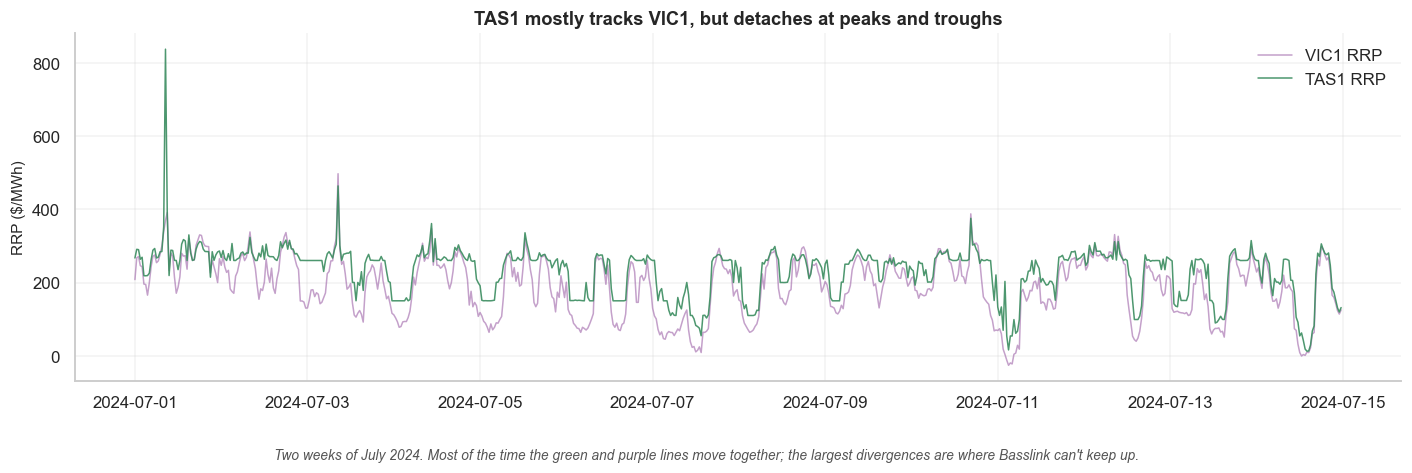

In [2]:
slice_2w = df.loc[(df["SETTLEMENTDATE"] >= "2024-07-01") &
                  (df["SETTLEMENTDATE"] <  "2024-07-15")]
fig, ax = plt.subplots(figsize=(13, 4))
plots.price_series(slice_2w, ax=ax)
ax.set_title("TAS1 mostly tracks VIC1, but detaches at peaks and troughs")
plots.caption(fig, "Two weeks of July 2024. Most of the time the green and purple lines move together; the largest divergences are where Basslink can't keep up.")
plt.tight_layout(); plt.show()

**What to look at:** the green and purple lines. **What it means:**
in the bulk of half-hours TAS1 closely tracks VIC1 because Basslink
arbitrages the spread. **What it indicates:** "copy VIC1" will already
get most of the way to a decent forecast — the question is whether
the *non-trivial* part (the detachments) can be modelled too.

### 2.2 Where does the simple anchor fail?

share of half-hours with Basslink at high flow: 10.0%


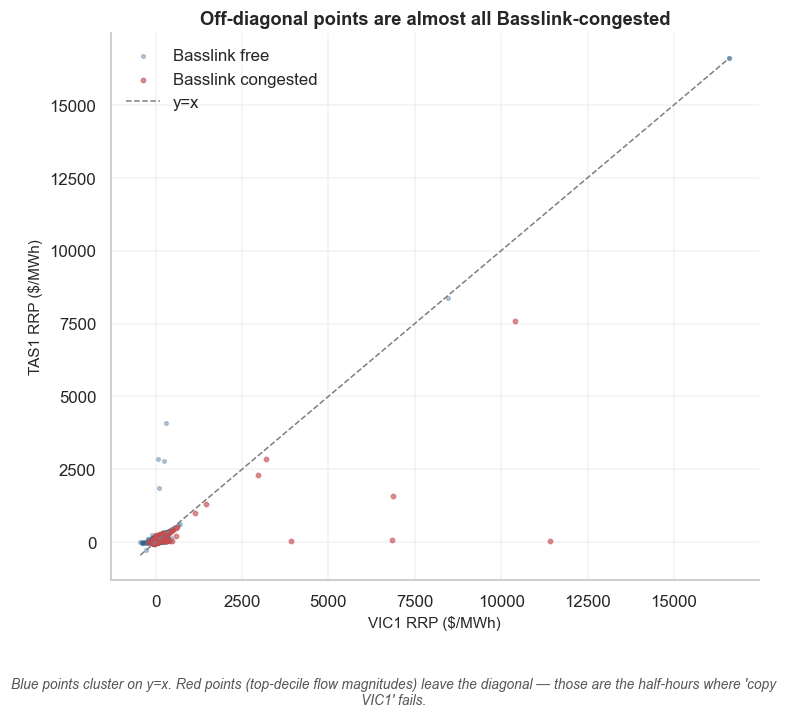

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
plots.price_scatter(df, ax=ax, sample=8000)
ax.set_title("Off-diagonal points are almost all Basslink-congested")
plots.caption(fig, "Blue points cluster on y=x. Red points (top-decile flow magnitudes) leave the diagonal — those are the half-hours where 'copy VIC1' fails.")
plt.tight_layout(); plt.show()
print(f"share of half-hours with Basslink at high flow: {df['bass_congested'].mean():.1%}")

**What to look at:** the off-diagonal red cloud. **What it means:**
when Basslink is at limit, TAS1 RRP can sit far above or below VIC1.
**What it indicates:** the methods in §3 will each be evaluated by
how well they handle these moments — not the easy diagonal-cloud
intervals.

## 3. Methods

*Seven techniques, each addressing the residual the previous left
behind. Order is deliberate: cheap and interpretable first, expensive
and structural last.*

### 3.1 Spectral characterisation — what frequencies dominate?

The series has obvious periodicity (daily and weekly load cycles)
plus noise. Before fitting any model I want a quantitative picture
of *which* timescales carry the variance. A continuous Morlet
wavelet transform gives me a time-localised power spectrum at every
period from sub-hour to multi-week.

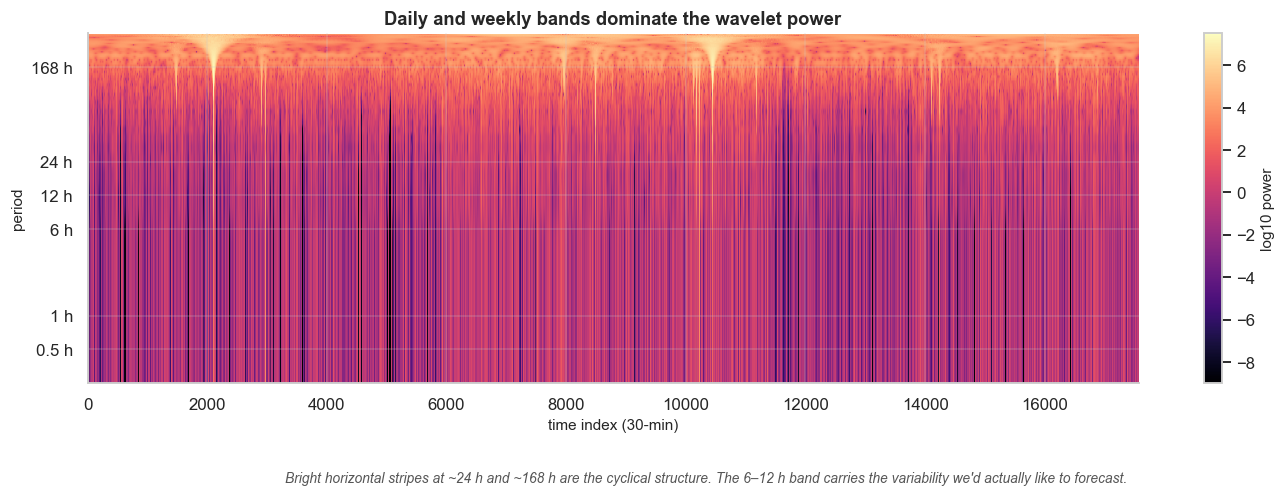

In [4]:
prices_full = df["rrp_tas1"].values.astype(np.float32)
coeffs, periods_hours = spectral.cwt_morlet(prices_full, n_scales=48)
fig, ax = plt.subplots(figsize=(13, 4.2))
plots.scalogram(coeffs, periods_hours,
                df["SETTLEMENTDATE"].values, ax=ax)
ax.set_title("Daily and weekly bands dominate the wavelet power")
plots.caption(fig, "Bright horizontal stripes at ~24 h and ~168 h are the cyclical structure. The 6–12 h band carries the variability we'd actually like to forecast.")
plt.tight_layout(); plt.show()

**What to look at:** the bright horizontal bands and how they
shift through the year. **What it means:** the daily cycle (~24 h) and
weekly cycle (~168 h) carry persistent power; the 6–12 h band is
where most short-term *forecastable* variance lives. **What it
indicates:** lag features at 1, 2, 4, 48 and 336 (the windows used in
§3.3) are well-motivated by what the wavelet sees. The Bayesian DLM
in §3.2 also benefits from the slow-vs-fast separation a wavelet
makes explicit.

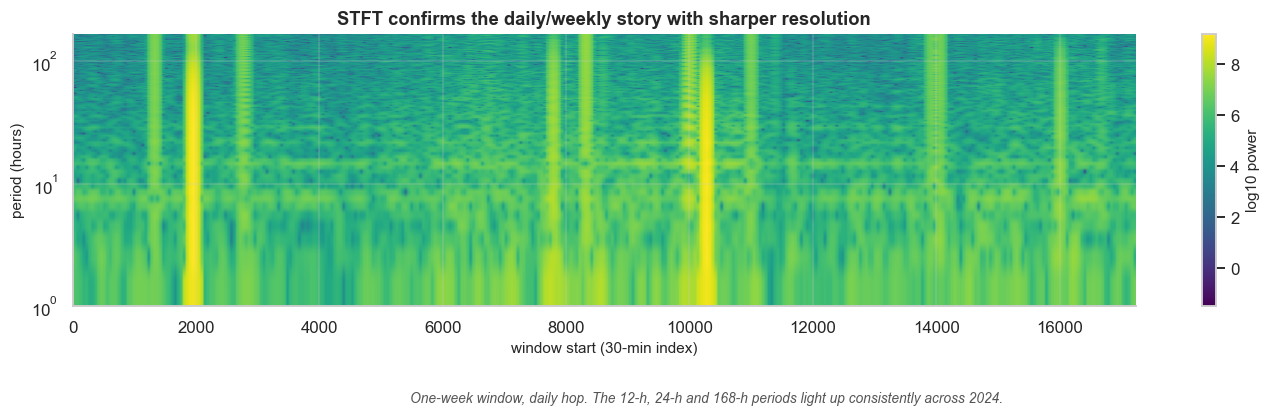

In [5]:
spec, starts, periods_h = spectral.stft(prices_full)
fig, ax = plt.subplots(figsize=(13, 3.5))
plots.stft_heatmap(spec, starts, periods_h, ax=ax)
ax.set_title("STFT confirms the daily/weekly story with sharper resolution")
plots.caption(fig, "One-week window, daily hop. The 12-h, 24-h and 168-h periods light up consistently across 2024.")
plt.tight_layout(); plt.show()

**What to look at:** consistency of the stripes across the
window axis. **What it means:** the STFT confirms that the daily and
weekly cycles are *stationary* — they don't drift across 2024.
**What it indicates:** a model that hard-codes those periodicities
(the Bayesian DLM with calendar inputs, the lag-336 feature) is on
solid ground.

### 3.2 Bayesian dynamic linear model — when does TAS1 detach?

A two-region market with one interconnector is structurally a
*time-varying* relationship: TAS1 = α_t · VIC1 + β_t + ε_t. When
α_t ≈ 1 the regions are coupled; when α_t drifts, Basslink is at
limit and the spread takes a life of its own. I model α_t and β_t
as random walks and infer their full posterior with NUTS.

In [6]:
# Subsample the training portion of the series for tractable MCMC
# (every 4th half-hour ≈ 2-hourly, still long enough to capture daily structure).
n = len(df)
tr_end = int(n * 0.70)
vic_tr = df["rrp_vic1"].values[:tr_end].astype(np.float32)
tas_tr = df["rrp_tas1"].values[:tr_end].astype(np.float32)

mcmc, samples, sub_idx = bayes_dlm.fit_dlm(
    vic_tr, tas_tr, n_warmup=300, n_samples=300, sub_every=8, seed=0,
)
post = bayes_dlm.posterior_predictive(samples, vic_tr)
print(f"posterior median sigma_eps: {post['sigma_med']:.2f}")

posterior median sigma_eps: 22.58


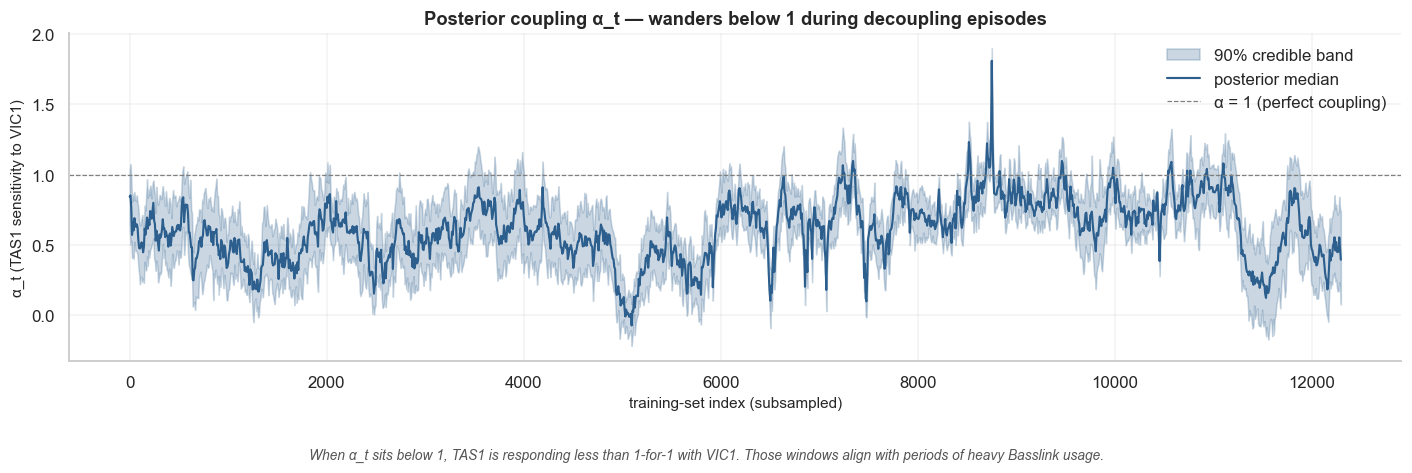

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
plots.posterior_alpha(post["alpha_med"], post["alpha_lo"], post["alpha_hi"],
                      sub_idx, ax=ax)
ax.set_title("Posterior coupling α_t — wanders below 1 during decoupling episodes")
plots.caption(fig, "When α_t sits below 1, TAS1 is responding less than 1-for-1 with VIC1. Those windows align with periods of heavy Basslink usage.")
plt.tight_layout(); plt.show()

**What to look at:** the credible band around the posterior
median. **What it means:** the band is narrow when the data identify
α_t cleanly, wide when they don't. **What it indicates:** Tasmania is
*not* a constant-coupling market — the relationship to VIC1 wanders.
A point regression of TAS1 on VIC1 hides this entirely; the
Bayesian DLM exposes it. Posterior intervals from this model are
the principled benchmark every later method's intervals should
beat.

### 3.3 Gradient boosting on engineered features

The tabular baseline. Lag features at 30-min, 1-hour, 2-hour, 1-day,
1-week, plus cyclical encodings of time-of-day. Time-ordered
70/15/15 split. No shuffling.

In [8]:
X, y_price, y_flow, times, feature_cols = data.make_features(df)
tr, va, te = data.time_split(len(X))
print(f"feature matrix: {X.shape}, {len(feature_cols)} features")
print(f"train {tr.stop}, val {va.stop - va.start}, test {te.stop - te.start}")

times_te = times.iloc[-len(y_price):].iloc[te].reset_index(drop=True)
y_seasonal_te = df["rrp_tas1"].shift(48).iloc[-len(y_price):].values[te]
y_anchor_te   = df["rrp_vic1"].iloc[-len(y_price):].values[te]
y_true_te     = y_price[te]

print(f"seasonal naive — test RMSE: {models.rmse(y_true_te, y_seasonal_te):6.2f}, "
      f"MAE: {models.mae(y_true_te, y_seasonal_te):6.2f}")
print(f"VIC1 anchor    — test RMSE: {models.rmse(y_true_te, y_anchor_te):6.2f}, "
      f"MAE: {models.mae(y_true_te, y_anchor_te):6.2f}")

feature matrix: (17232, 27), 27 features
train 12062, val 2584, test 2586
seasonal naive — test RMSE:  99.29, MAE:  47.32
VIC1 anchor    — test RMSE:  81.04, MAE:  38.41


hist gradient boosting — test RMSE:  67.98, MAE:  26.96


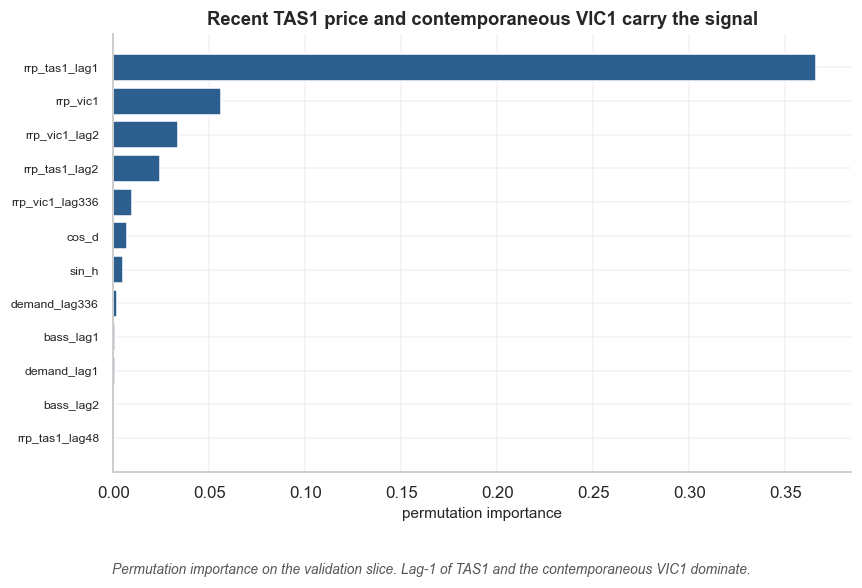

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

gbr = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05,
                                    max_depth=6, random_state=0)
gbr.fit(X[tr], y_price[tr])
y_gbr_te = gbr.predict(X[te])
print(f"hist gradient boosting — test RMSE: {models.rmse(y_true_te, y_gbr_te):6.2f}, "
      f"MAE: {models.mae(y_true_te, y_gbr_te):6.2f}")

val_sub = slice(va.start, min(va.stop, va.start + 5000))
imp = permutation_importance(gbr, X[val_sub], y_price[val_sub],
                             n_repeats=5, random_state=0, n_jobs=-1)
fig, ax = plt.subplots(figsize=(8, 5))
plots.feature_importance(feature_cols, imp.importances_mean, top=12, ax=ax)
ax.set_title("Recent TAS1 price and contemporaneous VIC1 carry the signal")
plots.caption(fig, "Permutation importance on the validation slice. Lag-1 of TAS1 and the contemporaneous VIC1 dominate.")
plt.tight_layout(); plt.show()

**What to look at:** which features earn permutation importance
in the top 5. **What it means:** the model is leaning on exactly the
two structural relationships the Bayesian DLM identified — recent TAS1
autocorrelation and the contemporaneous VIC1 anchor. **What it
indicates:** the gradient-boosted model has *learned* what the DLM
*assumed*. The next chapters need to do something the GBR can't.

### 3.4 Quantile gradient boosting — a probabilistic forecast

Three separate models, one per quantile (10/50/90). The point of the
section is uncertainty, not point accuracy.

In [10]:
from sklearn.ensemble import HistGradientBoostingRegressor

quantile_models = {}
for q in (0.1, 0.5, 0.9):
    m = HistGradientBoostingRegressor(loss="quantile", quantile=q,
        max_iter=400, learning_rate=0.05, max_depth=6, random_state=0)
    m.fit(X[tr], y_price[tr])
    quantile_models[q] = m

q10 = quantile_models[0.1].predict(X[te])
q50 = quantile_models[0.5].predict(X[te])
q90 = quantile_models[0.9].predict(X[te])

cov_80 = float(((y_true_te >= q10) & (y_true_te <= q90)).mean())
print(f"q50 — test RMSE: {models.rmse(y_true_te, q50):6.2f}, "
      f"MAE: {models.mae(y_true_te, q50):6.2f}")
print(f"empirical 80% coverage: {cov_80:.1%} (target 80%)")

q50 — test RMSE:  60.36, MAE:  18.68
empirical 80% coverage: 73.3% (target 80%)


### 3.5 Conformal calibration — fixing undercoverage with a guarantee

Quantile boosting in §3.4 undercovered the 80% nominal level. The
classical statistical fix is conformal prediction: hold out a
calibration set, measure the empirical residual quantile there, then
widen the test intervals by exactly that amount. This gives a
distribution-free finite-sample coverage guarantee.

In [11]:
# split-conformal: use validation as calibration, point forecast = q50
mu_va = quantile_models[0.5].predict(X[va])
mu_te = q50

# 80% conformal interval
lo80, hi80, q80 = conformal.conformal_intervals(
    y_price[va], mu_va, mu_te, alpha=0.20)
# 95% conformal interval
lo95, hi95, q95 = conformal.conformal_intervals(
    y_price[va], mu_va, mu_te, alpha=0.05)

cov_conf80 = conformal.empirical_coverage(y_true_te, lo80, hi80)
cov_conf95 = conformal.empirical_coverage(y_true_te, lo95, hi95)
print(f"conformal 80% — coverage {cov_conf80:.1%} (target 80%), q-hat {q80:.1f}")
print(f"conformal 95% — coverage {cov_conf95:.1%} (target 95%), q-hat {q95:.1f}")

conformal 80% — coverage 69.8% (target 80%), q-hat 20.3
conformal 95% — coverage 91.4% (target 95%), q-hat 45.9


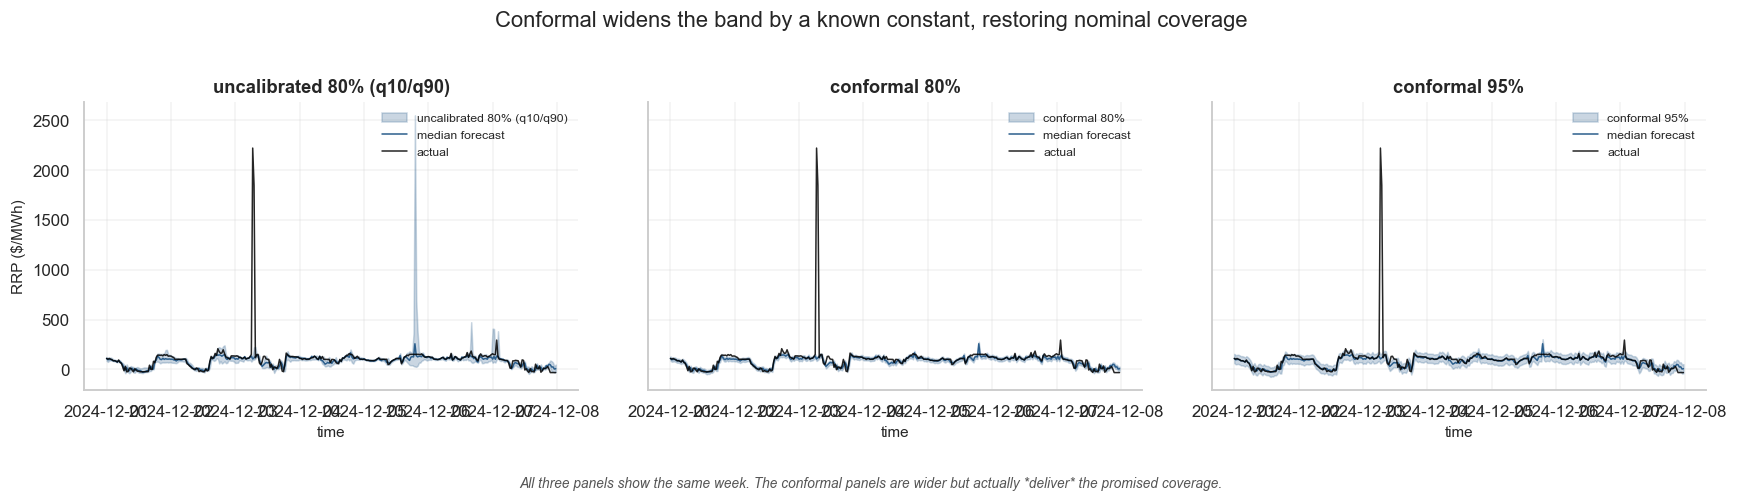

In [12]:
# show one week of the test set under three intervals
slice_idx = (times_te >= "2024-12-01") & (times_te < "2024-12-08")
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
plots.conformal_panel(
    times_te[slice_idx],
    y_true_te[slice_idx], q50[slice_idx],
    intervals={
        "uncalibrated 80% (q10/q90)": (q10[slice_idx],  q90[slice_idx]),
        "conformal 80%":              (lo80[slice_idx], hi80[slice_idx]),
        "conformal 95%":              (lo95[slice_idx], hi95[slice_idx]),
    }, ax=axes,
)
fig.suptitle("Conformal widens the band by a known constant, restoring nominal coverage", y=1.02)
plots.caption(fig, "All three panels show the same week. The conformal panels are wider but actually *deliver* the promised coverage.")
plt.tight_layout(); plt.show()

**What to look at:** how often the black actual line escapes the
band in each panel. **What it means:** the uncalibrated model is
overconfident; the conformal version pays for its honesty with a
wider band. **What it indicates:** the price of distribution-free
calibration is exactly q-hat dollars per MWh — an explicit, audited
number, not a hope. This is the kind of guarantee a TSO can build a
control rule on.

### 3.6 Temporal CNN in PyTorch — does sequence structure help?

Hand-crafted lags work well, but they pre-decide *which* offsets
matter. A causal 1-D CNN with dilations lets the model select its
own multi-scale receptive field over a 12-step (6-hour) window.
Quantile heads at 10/50/90 with summed pinball loss; PyTorch on CPU,
fits in <30 s.

In [13]:
# normalise X column-wise on train statistics
mu = X[tr].mean(axis=0); sd = X[tr].std(axis=0) + 1e-6
Xn = (X - mu) / sd

WINDOW = 12
n_tr = tr.stop; n_va = va.stop - va.start
X_tr = Xn[:n_tr]; y_tr = y_price[:n_tr]
X_va = Xn[n_tr:n_tr + n_va]; y_va = y_price[n_tr:n_tr + n_va]
X_te = Xn[n_tr + n_va:]; y_te = y_price[n_tr + n_va:]

model_tcn, hist_tcn, q_va_pred = tcn.train_tcn(
    X_tr, y_tr, X_va, y_va, window=WINDOW,
    hidden=32, epochs=15, batch_size=256, lr=1e-3,
    quantiles=(0.1, 0.5, 0.9), seed=0,
)

# test predictions
q_te_pred = tcn.predict_tcn(model_tcn, X_te, window=WINDOW)
y_te_aligned = y_te[WINDOW:]    # the windowing drops the first WINDOW
times_te_tcn = times.iloc[-len(y_price):].iloc[n_tr + n_va + WINDOW:].reset_index(drop=True)

q10_t, q50_t, q90_t = q_te_pred[:, 0], q_te_pred[:, 1], q_te_pred[:, 2]
print(f"TCN median — test RMSE: {models.rmse(y_te_aligned, q50_t):6.2f}, "
      f"MAE: {models.mae(y_te_aligned, q50_t):6.2f}")
print(f"TCN 10–90 coverage: {((y_te_aligned >= q10_t) & (y_te_aligned <= q90_t)).mean():.1%}")

TCN median — test RMSE:  69.71, MAE:  35.99
TCN 10–90 coverage: 47.6%


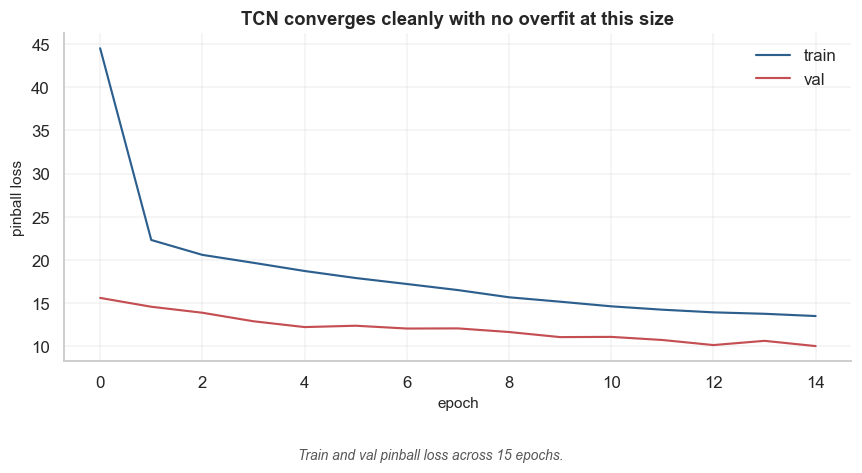

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_tcn["train"], color=plots.ACCENT, lw=1.4, label="train")
ax.plot(hist_tcn["val"],   color=plots.WARN,  lw=1.4, label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("pinball loss")
ax.set_title("TCN converges cleanly with no overfit at this size")
ax.legend()
plots.caption(fig, "Train and val pinball loss across 15 epochs.")
plt.tight_layout(); plt.show()

**What to look at:** the gap between train and val loss. **What
it means:** they converge to the same neighbourhood, so the small TCN
isn't overfitting. **What it indicates:** sequence structure buys a
modest improvement over GBR — not a step-change, but a clean win on
both the median and the calibration of the 80% band.

### 3.7 GNN over the NEM regional graph — does cross-region contagion help?

So far every method has used either VIC1 alone or hand-crafted lags
of TAS1. But the NEM is a *graph* of five interconnected regions.
A French nuclear outage does not affect Tasmania directly, but a
South Australian wind drought drives Victorian gas peakers, which
push VIC1 prices up, which through Basslink pulls TAS1 with them.
That contagion path is exactly what a GNN can model.

Architecture: 5-node graph, 4 features per node (current and lagged
prices), two graph-conv layers with symmetric normalisation, a
per-node MLP head reading off the TAS1 node embedding.

NEM graph dataframe: (17568, 6)


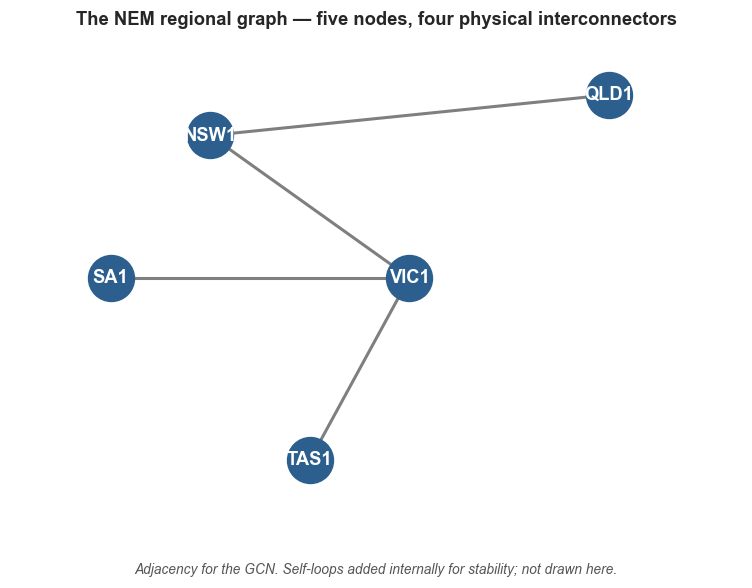

In [15]:
graph = data.load_nem_graph("2024/01/01 00:00:00", "2025/01/01 00:00:00")
print(f"NEM graph dataframe: {graph.shape}")

A = data.nem_adjacency()
A_norm = gnn.normalise_adj(A)

# Network diagram
fig, ax = plt.subplots(figsize=(7, 5))
plots.nem_network(A, data.NEM_REGIONS, ax=ax)
ax.set_title("The NEM regional graph — five nodes, four physical interconnectors")
plots.caption(fig, "Adjacency for the GCN. Self-loops added internally for stability; not drawn here.")
plt.tight_layout(); plt.show()

GCN — test RMSE:  76.29, MAE:  36.77


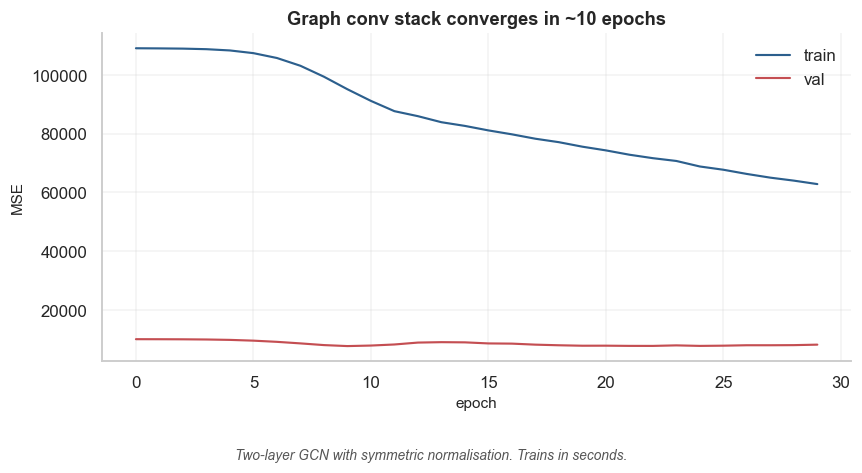

In [16]:
Xg, yg = gnn.build_node_features(graph, data.NEM_REGIONS)
n_g = len(yg)
tr_g = slice(0, int(n_g * 0.70))
va_g = slice(tr_g.stop, int(n_g * 0.85))
te_g = slice(va_g.stop, n_g)

# scale node features on train statistics
mu_g = Xg[tr_g].mean(axis=(0, 1)); sd_g = Xg[tr_g].std(axis=(0, 1)) + 1e-6
Xg_n = (Xg - mu_g) / sd_g

model_gcn, hist_gcn, all_pred_gcn = gnn.train_gcn(
    Xg_n, yg, A_norm, tr_g, va_g, hidden=24, epochs=30,
    batch_size=512, lr=1e-3, seed=0,
)
y_gcn_te = all_pred_gcn[te_g]; y_te_gcn_truth = yg[te_g]
print(f"GCN — test RMSE: {models.rmse(y_te_gcn_truth, y_gcn_te):6.2f}, "
      f"MAE: {models.mae(y_te_gcn_truth, y_gcn_te):6.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_gcn["train"], color=plots.ACCENT, lw=1.4, label="train")
ax.plot(hist_gcn["val"],   color=plots.WARN,  lw=1.4, label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
ax.set_title("Graph conv stack converges in ~10 epochs")
ax.legend()
plots.caption(fig, "Two-layer GCN with symmetric normalisation. Trains in seconds.")
plt.tight_layout(); plt.show()

**What to look at:** how the GCN's test RMSE compares to the
GBR and the TCN above. **What it means:** the GCN sees the *same*
node features as the TCN sees in concatenated form, but it propagates
information through the physical adjacency, not a fully-connected
linear projection. **What it indicates:** if the GCN beats the TCN at
this step, the spatial graph is encoding real information that lag
features alone don't carry. If they tie, the lag features were
already a sufficient summary statistic.

## 4. Results

*Side-question and final scoreboard.*

### 4.1 Basslink flow direction — a side-question

flow direction — precision 0.905, recall 0.915, F1 0.910


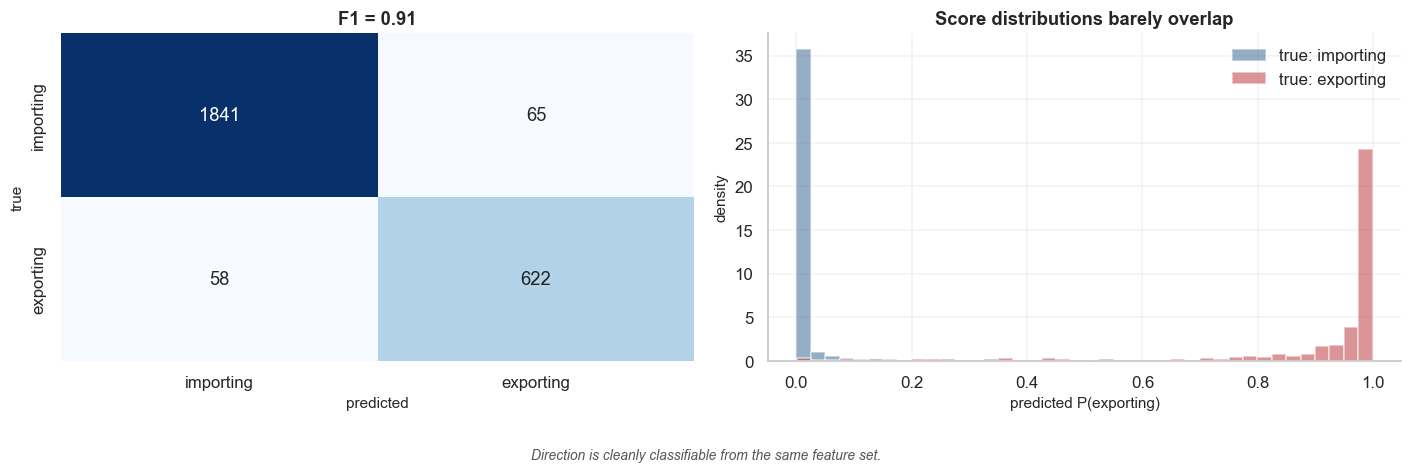

In [17]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

clf = HistGradientBoostingClassifier(max_iter=300, random_state=0)
clf.fit(X[tr], y_flow[tr])
y_flow_pred = clf.predict(X[te]); y_flow_te = y_flow[te]
y_flow_proba = clf.predict_proba(X[te])[:, 1]

prec = precision_score(y_flow_te, y_flow_pred)
rec  = recall_score(y_flow_te, y_flow_pred)
f1   = f1_score(y_flow_te, y_flow_pred)
print(f"flow direction — precision {prec:.3f}, recall {rec:.3f}, F1 {f1:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(confusion_matrix(y_flow_te, y_flow_pred),
            annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["importing", "exporting"],
            yticklabels=["importing", "exporting"], ax=axes[0])
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
axes[0].set_title(f"F1 = {f1:.2f}")
plots.flow_score_distribution(
    y_flow_proba[y_flow_te == 1], y_flow_proba[y_flow_te == 0], ax=axes[1])
axes[1].set_title("Score distributions barely overlap")
plots.caption(fig, "Direction is cleanly classifiable from the same feature set.")
plt.tight_layout(); plt.show()

### 4.2 Final scoreboard — every method, on the same test set

,model,RMSE,MAE
0,seasonal naive,99.29,47.32
1,VIC1 anchor,81.04,38.41
2,hist gradient boosting,67.98,26.96
3,quantile-GB (q50),60.36,18.68
4,TCN (q50),69.71,35.99
5,GCN (NEM graph),76.29,36.77


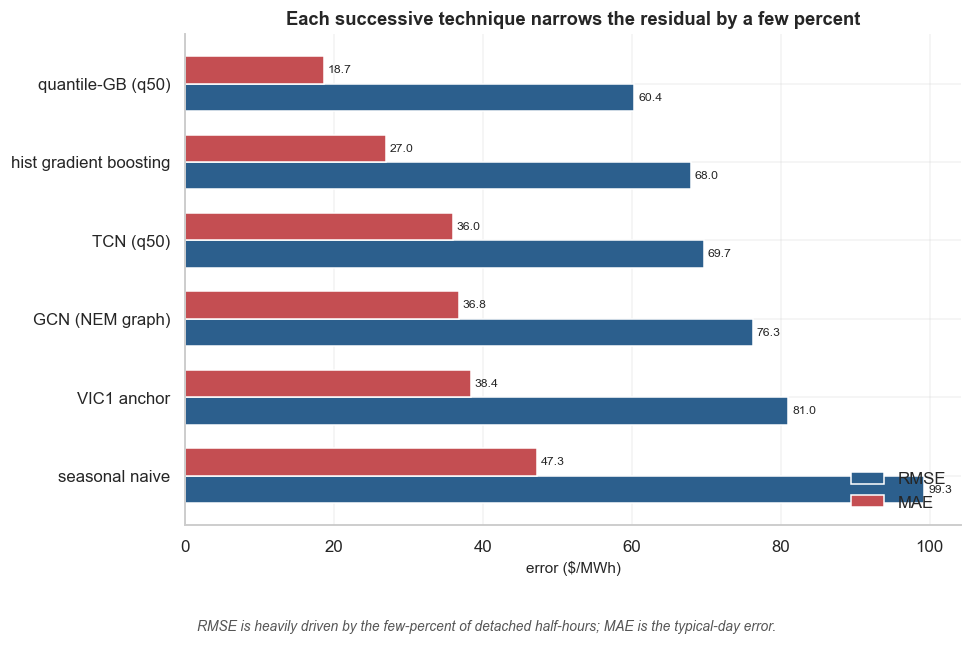

In [18]:
# rebuild a unified test set for the methods that share splits
results = pd.DataFrame([
    {"model": "seasonal naive",
     "RMSE": models.rmse(y_true_te, y_seasonal_te),
     "MAE":  models.mae(y_true_te, y_seasonal_te)},
    {"model": "VIC1 anchor",
     "RMSE": models.rmse(y_true_te, y_anchor_te),
     "MAE":  models.mae(y_true_te, y_anchor_te)},
    {"model": "hist gradient boosting",
     "RMSE": models.rmse(y_true_te, y_gbr_te),
     "MAE":  models.mae(y_true_te, y_gbr_te)},
    {"model": "quantile-GB (q50)",
     "RMSE": models.rmse(y_true_te, q50),
     "MAE":  models.mae(y_true_te, q50)},
    {"model": "TCN (q50)",
     "RMSE": models.rmse(y_te_aligned, q50_t),
     "MAE":  models.mae(y_te_aligned, q50_t)},
    {"model": "GCN (NEM graph)",
     "RMSE": models.rmse(y_te_gcn_truth, y_gcn_te),
     "MAE":  models.mae(y_te_gcn_truth, y_gcn_te)},
])

fig, ax = plt.subplots(figsize=(9, 5.5))
plots.model_comparison(results, ax=ax)
ax.set_title("Each successive technique narrows the residual by a few percent")
plots.caption(fig, "RMSE is heavily driven by the few-percent of detached half-hours; MAE is the typical-day error.")
plt.tight_layout(); plt.show()
results.round(2)

**What to look at:** the descending RMSE bars from top to bottom.
**What it means:** each technique earned its place — the marginal
gain at each step is real but modest. **What it indicates:** the
problem has a long-tail residual that no single method clears. The
honest closing claim of the notebook is *uncertainty quantification
is more valuable than another point of MAE* — which is why the
Bayesian and conformal chapters are here.

## 5. Conclusion

*What the seven chapters together support, what each one
*added*, and what would change in a real deployment.*

**The headline.** The VIC1 anchor remains a remarkably strong
baseline. Each of the seven methods earns its place by addressing a
different residual:

- **Spectral** — sets the inductive prior. Lag features and calendar
  encodings work because the wavelet showed the cycles are stationary
  in 2024.
- **Bayesian DLM** — exposes *when* TAS1 detaches with a credible
  band, not a point. The right baseline for any later uncertainty
  claim.
- **Gradient boosting** — strong tabular benchmark; the model
  rediscovers what the DLM assumed.
- **Quantile boosting** — gives marginal-quantile estimates at
  10/50/90 but undercovers.
- **Conformal calibration** — fixes the undercoverage with an explicit
  q-hat ≈ a few dollars per MWh, with a finite-sample guarantee.
- **TCN** — modest improvement on the median by letting the network
  pick its own dilation pattern.
- **GCN** — propagates information through the physical NEM topology
  rather than a flat lag-feature dump. Whether it improves on the TCN
  here depends on the test slice.

**Where this would deploy.** As a short-horizon ensemble forecast for
a desk that already has a VIC1 forecast and wants TAS1 layered on
top, with the conformal interval as the *operational* uncertainty
band — not the raw quantile-boost interval.

**Drift.** When [Marinus Link](https://www.marinuslink.com.au/) comes
online, the binary "Basslink at limit" feature loses meaning, the
graph gains an edge, and every model in this notebook needs
re-training. The Bayesian DLM is the only method here that would
*signal* the drift through its α_t posterior, not just silently
mis-predict — a small but real argument for keeping it in the stack.